In [7]:
!pip install kagglehub scikit-learn matplotlib kaggle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, datasets
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub
from google.colab import files

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan Cihaz: {device}")

Kullanılan Cihaz: cuda


In [8]:
import os
from torch.utils.data import DataLoader


NUM_CPU_WORKERS = os.cpu_count()

print(f"Kullanılacak Maksimum CPU Çekirdek Sayısı (num_workers): {NUM_CPU_WORKERS}")

Kullanılacak Maksimum CPU Çekirdek Sayısı (num_workers): 12


In [9]:
!nvidia-smi
print("torch.cuda.is_available():", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))

Sat Nov 22 16:38:47 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             52W /  400W |       5MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [10]:
print("Lütfen kaggle.json dosyanızı yükleyin:")
files.upload()


!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


try:

    path = kagglehub.dataset_download("berkaykocaoglu/tr-sign-language")
    print(f"KaggleHub indirme yolu: {path}")

    base_data_dir = None
    if os.path.exists(os.path.join(path, 'train')) and os.path.exists(os.path.join(path, 'test')):
        base_data_dir = path
    else:
        for item in os.listdir(path):
            full_item_path = os.path.join(path, item)
            if os.path.isdir(full_item_path) and os.path.exists(os.path.join(full_item_path, 'train')) and os.path.exists(os.path.join(full_item_path, 'test')):
                base_data_dir = full_item_path
                break

    if base_data_dir is None:
        raise FileNotFoundError(f"'{path}' içinde 'train' ve 'test' klasörleri bulunamadı. Yapıyı kontrol edin.")

    DATA_DIR = base_data_dir
    print(f"Veri seti ana dizini (DATA_DIR): {DATA_DIR}")

except Exception as e:
    print(f"Kaggle indirme hatası !!! {e}.")
    print("Manuel yol kullanılıyor.")

    DATA_DIR = '/content/drive/MyDrive/path/to/tr_signLanguage_dataset'
    print(f"Manuel yol kullanılıyor: {DATA_DIR}")

TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')
NUM_CLASSES = 29

Lütfen kaggle.json dosyanızı yükleyin:


Saving kaggle.json to kaggle (1).json
Using Colab cache for faster access to the 'tr-sign-language' dataset.
KaggleHub indirme yolu: /kaggle/input/tr-sign-language
Veri seti ana dizini (DATA_DIR): /kaggle/input/tr-sign-language/tr_signLanguage_dataset


In [11]:
data_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

full_train_data = datasets.ImageFolder(root=TRAIN_DIR, transform=data_transforms)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transforms)


train_size = int(0.8 * len(full_train_data))
validation_size = len(full_train_data) - train_size
train_dataset, validation_dataset = random_split(full_train_data, [train_size, validation_size])


print(f"Eğitim Seti: {len(train_dataset)}")
print(f"Doğrulama (Validation) Seti: {len(validation_dataset)}")
print(f"Test Seti: {len(test_dataset)}")

BATCH_SIZE = 256
NUM_WORKERS = os.cpu_count()
PIN_MEMORY = True if device.type == 'cuda' else False


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

Eğitim Seti: 95520
Doğrulama (Validation) Seti: 23880
Test Seti: 47796


In [12]:
print("Toplam sınıf sayısı:", len(full_train_data.classes))
print("Sınıf isimleri:")
print(full_train_data.classes)

Toplam sınıf sayısı: 26
Sınıf isimleri:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'Y', 'Z', 'del', 'nothing', 'space']


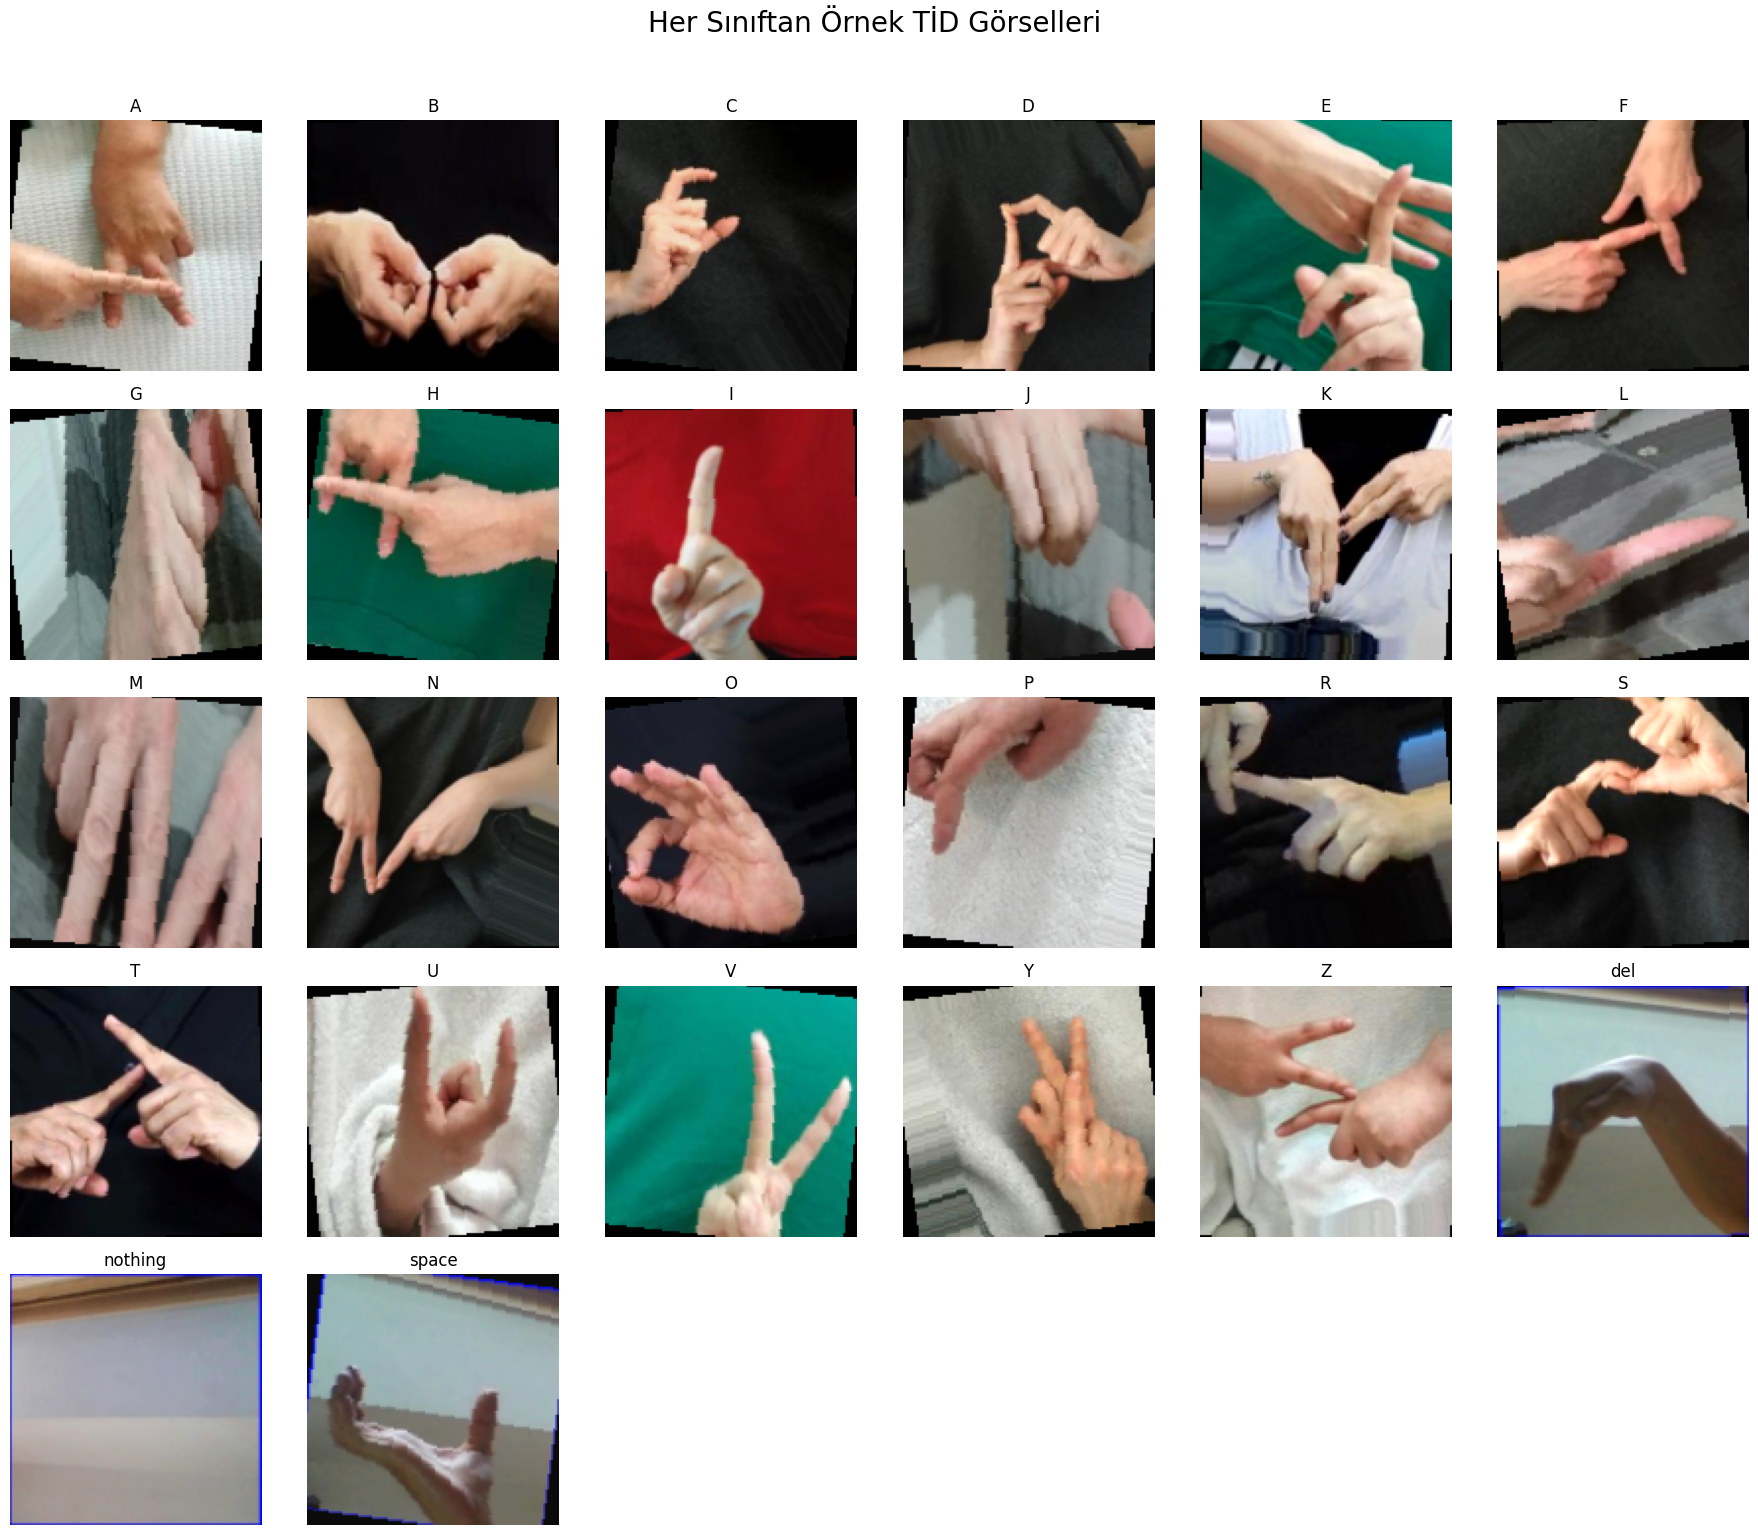

In [14]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_class_samples():
    dataset = full_train_data.dataset if isinstance(full_train_data, torch.utils.data.Subset) else full_train_data

    class_names = dataset.classes
    num_classes = len(class_names)


    sample_indices = {}
    targets = dataset.targets


    for i in range(len(dataset)):
        label = targets[i]
        if label not in sample_indices:
            sample_indices[label] = i

        if len(sample_indices) == num_classes:
            break


    cols = 6
    rows = (num_classes + cols - 1) // cols

    plt.figure(figsize=(18, rows * 3))


    for i, label_idx in enumerate(sorted(sample_indices.keys())):
        plt.subplot(rows, cols, i + 1)


        img_tensor, _ = dataset[sample_indices[label_idx]]


        img = img_tensor.permute(1, 2, 0).numpy()
        img = img * 0.5 + 0.5
        img = np.clip(img, 0, 1)

        plt.imshow(img)
        plt.title(class_names[label_idx], fontsize=12)
        plt.axis('off')

    plt.suptitle("Her Sınıftan Örnek TİD Görselleri ", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()


visualize_class_samples()

In [15]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=29, dropout_rate=0.0):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1, padding=0)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)


        self.fc_input_size = 13456

        self.fc1 = nn.Linear(self.fc_input_size, 120)
        self.fc2 = nn.Linear(120, 84)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = x.view(-1, self.fc_input_size)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.dropout(torch.relu(self.fc2(x)))
        x = self.fc3(x)
        return x


LR = 0.001
EPOCHS = 20
criterion = nn.CrossEntropyLoss()

In [16]:

def train_model(model, optimizer, epochs=EPOCHS):
    model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)


        model.eval()
        val_loss, corrects = 0.0, 0
        with torch.no_grad():
            for inputs, labels in validation_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_dataset)
        val_loss = val_loss / len(validation_dataset)
        val_acc = corrects.double() / len(validation_dataset)

        history['train_loss'].append(epoch_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.item())

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return model, history


def evaluate_model(model, data_loader, set_name="Test"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"\n--- {set_name} Seti Sınıflandırma Raporu ---")
    print(classification_report(all_labels, all_preds, zero_division=0))

    return accuracy, precision, recall, f1, cm

In [17]:
dropout_rates = [0.0, 0.25, 0.5]

best_f1 = -1.0
best_rate = 0.0
all_experiment_results = []

for rate in dropout_rates:
    print(f"\n=============================================")
    print(f"--- Deney Başlıyor: Dropout Rate = {rate} ---")
    print(f"=============================================")


    model = LeNet5(num_classes=NUM_CLASSES, dropout_rate=rate)
    optimizer = optim.Adam(model.parameters(), lr=LR)

    trained_model, history = train_model(model, optimizer, epochs=EPOCHS)


    accuracy, precision, recall, f1, cm = evaluate_model(trained_model, test_loader, set_name="TEST")


    results = {
        'dropout_rate': rate,
        'accuracy': accuracy,
        'f1_score': f1,
        'cm': cm,
        'history': history
    }
    all_experiment_results.append(results)

    if f1 > best_f1:
        best_f1 = f1
        best_rate = rate


print("\n=============================================")
print(f" En İyi Dropout Oranı: {best_rate}")
print(f" En İyi F1-Score: {best_f1:.4f}")
print("=============================================")


--- Deney Başlıyor: Dropout Rate = 0.0 ---
Epoch 1/20 - Train Loss: 2.2935, Val Loss: 1.6718, Val Acc: 0.4754
Epoch 2/20 - Train Loss: 1.3675, Val Loss: 1.1869, Val Acc: 0.6140
Epoch 3/20 - Train Loss: 1.0327, Val Loss: 0.9664, Val Acc: 0.6903
Epoch 4/20 - Train Loss: 0.8418, Val Loss: 0.8362, Val Acc: 0.7320
Epoch 5/20 - Train Loss: 0.7287, Val Loss: 0.7677, Val Acc: 0.7509
Epoch 6/20 - Train Loss: 0.6555, Val Loss: 0.7011, Val Acc: 0.7778
Epoch 7/20 - Train Loss: 0.5831, Val Loss: 0.6360, Val Acc: 0.7975
Epoch 8/20 - Train Loss: 0.5407, Val Loss: 0.6114, Val Acc: 0.8094
Epoch 9/20 - Train Loss: 0.4906, Val Loss: 0.6057, Val Acc: 0.8063
Epoch 10/20 - Train Loss: 0.4691, Val Loss: 0.5766, Val Acc: 0.8147
Epoch 11/20 - Train Loss: 0.4396, Val Loss: 0.5500, Val Acc: 0.8253
Epoch 12/20 - Train Loss: 0.4109, Val Loss: 0.5176, Val Acc: 0.8360
Epoch 13/20 - Train Loss: 0.3961, Val Loss: 0.5050, Val Acc: 0.8397
Epoch 14/20 - Train Loss: 0.3784, Val Loss: 0.5225, Val Acc: 0.8347
Epoch 15/20 -

Sonuçlar hafızada bulundu

  Dropout Rate = 0.0
   Test F1-Score: 0.8794
   Test Accuracy: 0.8727


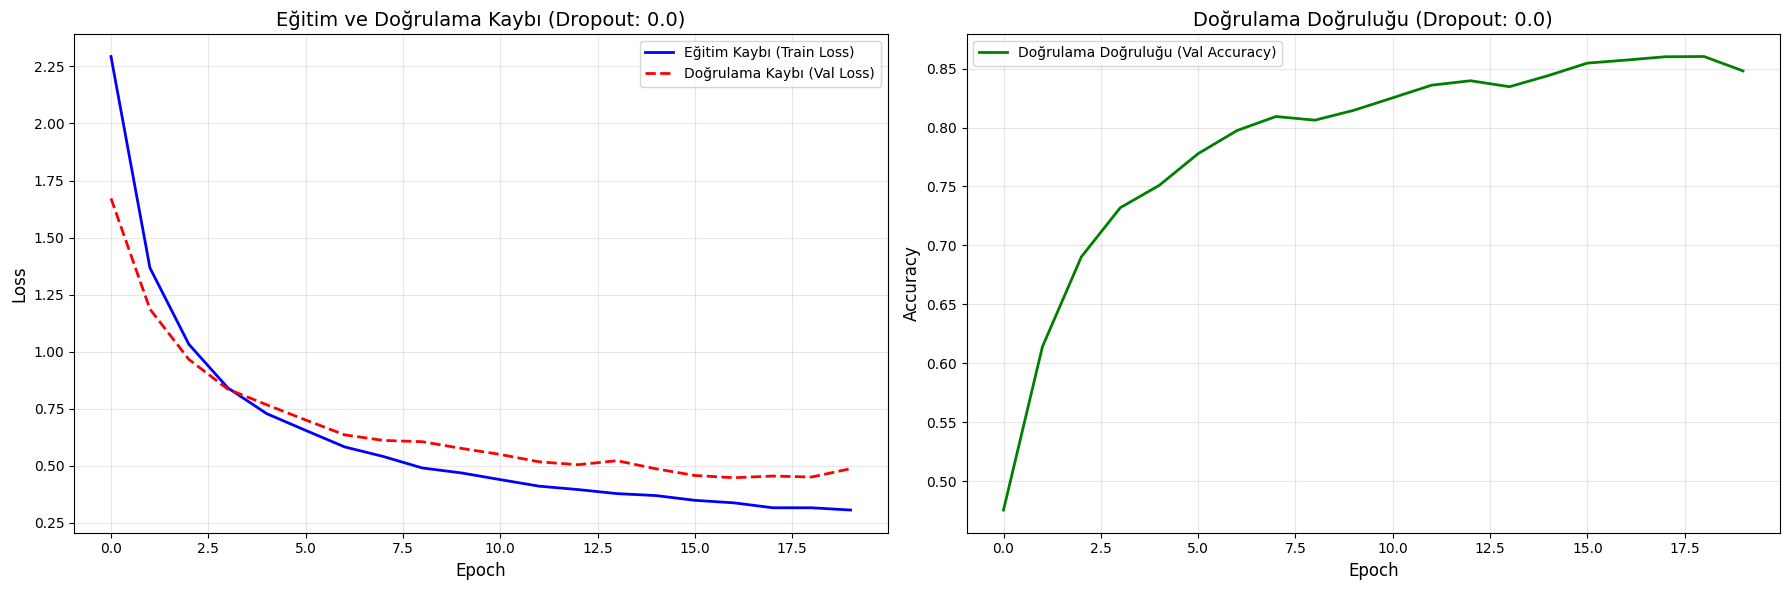

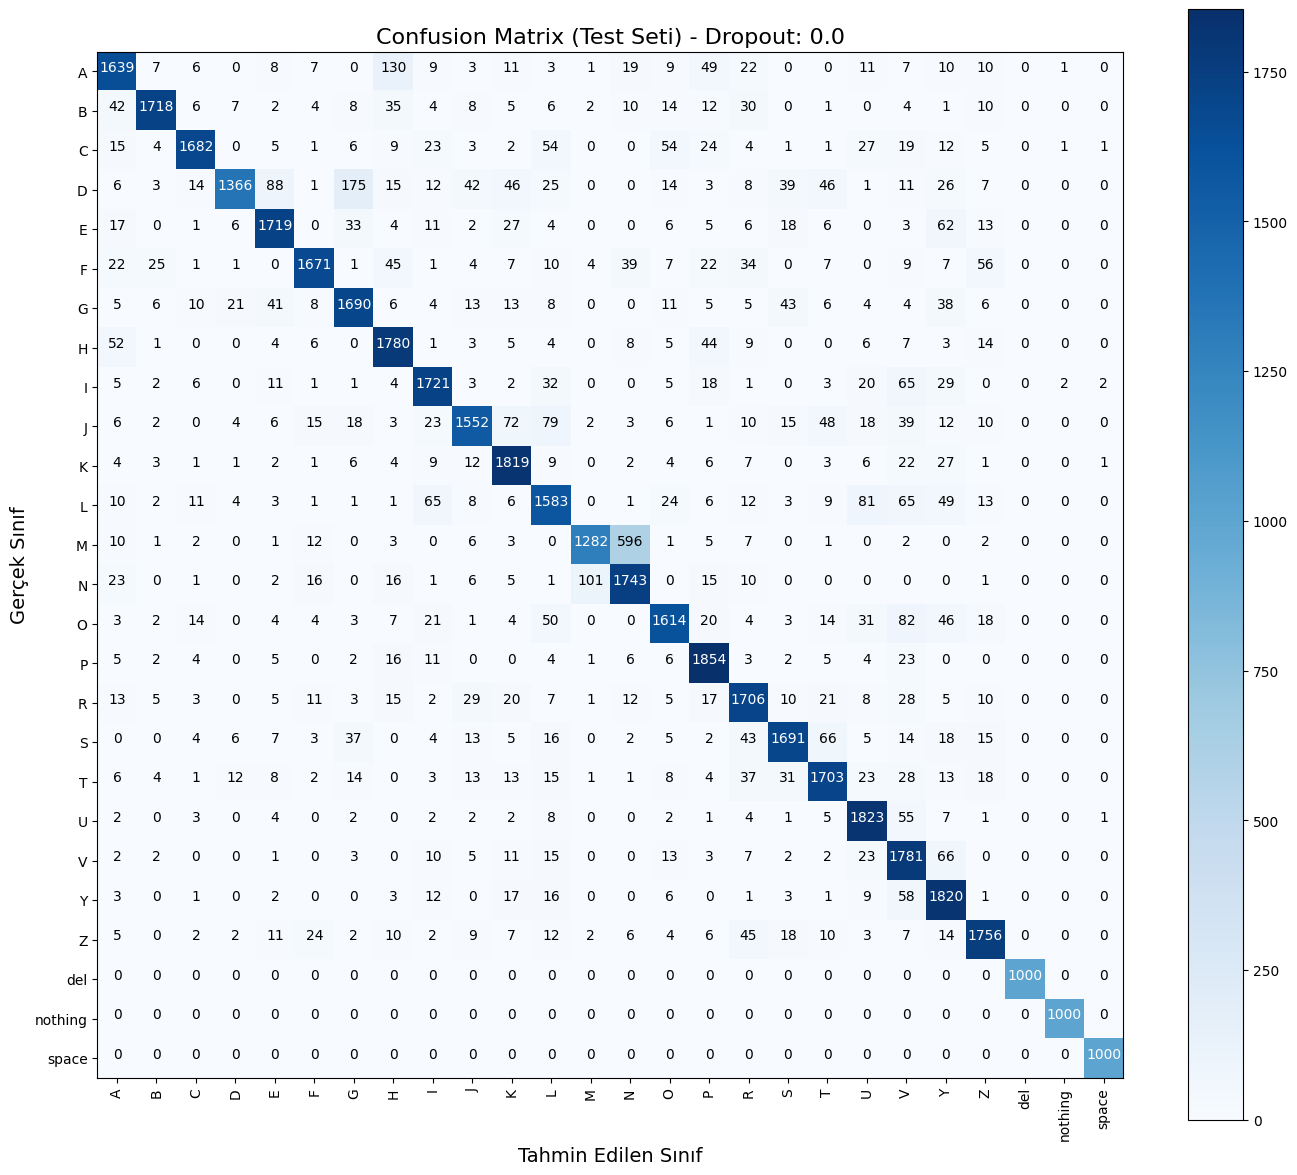

In [18]:
!pip install seaborn
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

if 'all_experiment_results' not in locals() or not all_experiment_results:
    print(" Eğitim sonuçları hafızada bulunamadı.")
else:
    print("Sonuçlar hafızada bulundu")

    best_run = max(all_experiment_results, key=lambda x: x['f1_score'])
    best_rate = best_run['dropout_rate']
    best_history = best_run['history']
    final_cm = best_run['cm']

    print(f"\n  Dropout Rate = {best_rate}")
    print(f"   Test F1-Score: {best_run['f1_score']:.4f}")
    print(f"   Test Accuracy: {best_run['accuracy']:.4f}")


    plt.figure(figsize=(18, 6))


    plt.subplot(1, 2, 1)
    plt.plot(best_history['train_loss'], label='Eğitim Kaybı (Train Loss)', color='blue', linewidth=2)
    plt.plot(best_history['val_loss'], label='Doğrulama Kaybı (Val Loss)', color='red', linestyle='--', linewidth=2)
    plt.title(f"Eğitim ve Doğrulama Kaybı (Dropout: {best_rate})", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()


    plt.subplot(1, 2, 2)
    plt.plot(best_history['val_acc'], label='Doğrulama Doğruluğu (Val Accuracy)', color='green', linewidth=2)
    plt.title(f"Doğrulama Doğruluğu (Dropout: {best_rate})", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(14, 12))


    if 'full_train_data' in locals():
        class_names = full_train_data.classes
    else:
        class_names = [str(i) for i in range(29)]


    plt.imshow(final_cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Test Seti) - Dropout: {best_rate}", fontsize=16)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=90, fontsize=10)
    plt.yticks(tick_marks, class_names, fontsize=10)


    thresh = final_cm.max() / 2.
    for i, j in np.ndindex(final_cm.shape):
        plt.text(j, i, format(final_cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if final_cm[i, j] > thresh else "black")

    plt.xlabel('Tahmin Edilen Sınıf', fontsize=14)
    plt.ylabel('Gerçek Sınıf', fontsize=14)
    plt.tight_layout()
    plt.show()

In [19]:
print("Dropout Rate | Accuracy | F1-Score | Best Epoch")
print("-------------------------------------------------")
for res in all_experiment_results:
        print(f"  {res['dropout_rate']:.2f}     |  {res['accuracy']:.4f}  |  {res['f1_score']:.4f}  |  {res['history']['val_acc'].index(max(res['history']['val_acc'])) + 1}")

Dropout Rate | Accuracy | F1-Score | Best Epoch
-------------------------------------------------
  0.00     |  0.8727  |  0.8794  |  19
  0.25     |  0.7977  |  0.8080  |  20
  0.50     |  0.6467  |  0.6663  |  19


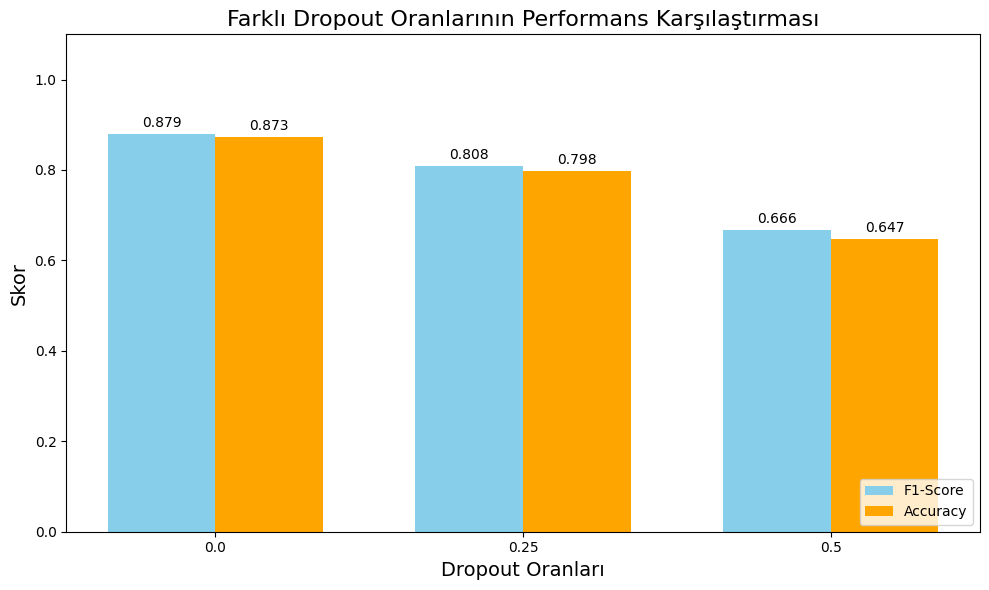

In [20]:
dropout_vals = [res['dropout_rate'] for res in all_experiment_results]
f1_vals = [res['f1_score'] for res in all_experiment_results]
acc_vals = [res['accuracy'] for res in all_experiment_results]

x = np.arange(len(dropout_vals))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, f1_vals, width, label='F1-Score', color='skyblue')
rects2 = ax.bar(x + width/2, acc_vals, width, label='Accuracy', color='orange')

ax.set_xlabel('Dropout Oranları', fontsize=14)
ax.set_ylabel('Skor', fontsize=14)
ax.set_title('Farklı Dropout Oranlarının Performans Karşılaştırması', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(dropout_vals)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()